# Synthetischer Datensatz — Drift-Erkennung

Wendet die vier Drift-Detektoren KSWIN, ADWIN, DDM und EDDM (`drift_detection.py`) auf den normierten Prädiktionsfehler des drift-behafteten Stroms an; Tuning und Kennzahlen über das gesamte Jahr (4 Sudden Drifts).

In [1]:
FORCE_RECOMPUTE = False
IS_FINAL = True

In [2]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

Daten laden: test_data.pkl aus dem Modell-Notebook

In [3]:
# --- Konstanten ---
RUN_ID = "ddf725f0"   # None -> neuestes Modell

SEED = 42

DETECTORS = ("KSWIN", "ADWIN", "DDM", "EDDM", "RMSE")
TOLERANCE = 1000
N_TRIALS  = {
    "KSWIN": 40,
    "ADWIN": 40,
    "RMSE": 40,
    "DDM": 200,
    "EDDM": 200,
}
COOLDOWN  = 5000

In [4]:
import numpy as np
from src.utils import run_registry as rr

data_store = rr.synthetic_data_store(data_dir)
model_store = rr.synthetic_model_store(model_dir)

if RUN_ID is None:
    run_id = model_store.latest_id("model")
    if run_id is None:
        raise FileNotFoundError("Kein data-Artefakt. Bitte syn_model.ipynb ausfuehren.")
else:
    run_id = RUN_ID
print(f"model run_id = {run_id}")

rng = np.random.default_rng(SEED)
test_data = data_store.load("data_test", run_id=run_id, rename=True, rekey=True)
test_cfg = rr.RunConfig.from_document(test_data.attrs.get("config", test_data.attrs))

ledger = rr.run_ledger(work_dir)
ledger.bind("detections", parents={"model": test_cfg.id})
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

model run_id = ddf725f0


## Drift-Erkennung

In [5]:
import drift_detection as dd

error_stream = np.nan_to_num(test_data["pred_error_norm_cd"].to_numpy())
cd_signal = test_data["cd"].to_numpy()
print(f"Fehlerstrom: {len(error_stream)} Zeitschritte")

Fehlerstrom: 525600 Zeitschritte


## Parameter-Tuning (Optuna)

In [6]:
from types import SimpleNamespace
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sudden_idx = dd.sudden_drift_indices(cd_signal, jump=1e-9)
drift_active = dd.drift_active_mask(cd_signal, rel_floor=0.1)

det_cfg = test_cfg.compose(detector={"detectors": DETECTORS, "n_trials": N_TRIALS,
                     "tolerance": TOLERANCE, "weights": [3.0, 0.3, 0.05],
                     "downsample": 5, "cooldown": COOLDOWN})

_tuning_loaded_from_cache = model_store.exists("detect_tuning", det_cfg, rekey=True) and not FORCE_RECOMPUTE
if _tuning_loaded_from_cache:
    _tuning = model_store.load("detect_tuning", det_cfg, rename=True, rekey=True)
else:
    _tuning = {"best_params": {}, "user_attrs": {}, "best_value": {}}

_retuned = False
studies, best_params = {}, {}

for _name in DETECTORS:
    if _name in _tuning["best_params"]:
        best_params[_name] = _tuning["best_params"][_name]
        studies[_name] = SimpleNamespace(
            best_value=_tuning["best_value"][_name],
            best_trial=SimpleNamespace(user_attrs=_tuning["user_attrs"][_name]))
        print(f"{_name:6s} aus Cache geladen")
        continue
    print(f"{_name:6s} wird getunt...")
    studies[_name] = dd.tune_detector(
        _name, error_stream, sudden_idx, drift_active,
        tolerance=TOLERANCE, n_trials=N_TRIALS[_name], downsample=5, seed=SEED,
        weights=(3.0, 0.3, 0.05))
    best_params[_name] = studies[_name].best_params
    _tuning["best_params"][_name] = best_params[_name]
    _tuning["user_attrs"][_name] = dict(studies[_name].best_trial.user_attrs)
    _tuning["best_value"][_name] = float(studies[_name].best_value)
    _retuned = True
    print(f"{_name:6s} tuning abgeschlossen: score={studies[_name].best_value:.3f} ")

if _retuned:
    model_store.save(_tuning, "detect_tuning", det_cfg)

for _name in DETECTORS:
    a = studies[_name].best_trial.user_attrs
    print(f"{_name:6s} score={studies[_name].best_value:.3f} | recall={a['recall']:.2f} "
          f"delay={a['mean_delay']:.0f} false={a['n_false']:3d} -> {best_params[_name]}")

KSWIN  aus Cache geladen
ADWIN  aus Cache geladen
DDM    aus Cache geladen
EDDM   aus Cache geladen
RMSE   aus Cache geladen
KSWIN  score=0.465 | recall=1.00 delay=43 false= 32 -> {'min_num_instances': 54, 'alpha': 1.0730311740975027e-06, 'num_test_instances': 23}
ADWIN  score=0.609 | recall=1.00 delay=90 false= 38 -> {'delta': 0.002517925420866116, 'clock': 55, 'min_window_size': 51}
DDM    score=0.100 | recall=1.00 delay=66 false=  0 -> {'drift_level': 2.107732644096296, 'warning_level': 1.4393624244901235, 'min_num_instances': 208, 'err_threshold': 8.005479106704072}
EDDM   score=0.106 | recall=1.00 delay=71 false=  0 -> {'alpha': 0.9648524424498482, 'beta': 0.9556215709046562, 'min_num_misclassified_instances': 37, 'err_threshold': 22.74766332818464}
RMSE   score=0.075 | recall=1.00 delay=25 false=  3 -> {'window': 40, 'threshold': 3.9860578611160244}


c:\git\process_optimization_concept_drift\venv_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Vergleich der getunten Detektoren

In [7]:
det_run = det_cfg
_detections_loaded_from_cache = model_store.exists("detections", det_run, rekey=True) and not FORCE_RECOMPUTE and not _retuned
if _detections_loaded_from_cache:
    _det_cache = model_store.load("detections", det_run, rename=True, rekey=True)
    tuned = _det_cache["tuned"]
    for _name in ["KSWIN", "ADWIN", "DDM", "EDDM"]:
        print(f"{_name:6s}: {len(tuned[_name][0]):3d} Drift(s) (getunt)")
    plot_thinned = _det_cache["plot_thinned"]
    for _name in ["KSWIN", "ADWIN"]:
        print(f"{_name:6s}: {len(plot_thinned[_name][0]):3d} Drift(s) "
              f"(plot-cooldown={COOLDOWN}, aus Cache)")
else:
    tuned = {}
    for _name, _p in best_params.items():
        _p = dict(_p)
        _et = _p.pop("err_threshold", 0.5)
        _det = dd.build_detector(_name, **_p)
        tuned[_name] = dd.run_detector(_name, _det, error_stream, err_threshold=_et)
        print(f"{_name:6s}: {len(tuned[_name][0]):3d} Drift(s) (getunt)")
    plot_thinned = {}
    for _name in ["KSWIN", "ADWIN"]:
        _p = dict(best_params[_name]); _p.pop("err_threshold", None)
        _det = dd.build_detector(_name, **_p)
        plot_thinned[_name] = dd.run_detector(_name, _det, error_stream, cooldown=COOLDOWN)
        print(f"{_name:6s}: {len(plot_thinned[_name][0]):3d} Drift(s) (plot-cooldown={COOLDOWN})")
    model_store.save({"tuned": tuned, "plot_thinned": plot_thinned}, "detections", det_run)

KSWIN : 854 Drift(s) (getunt)
ADWIN : 1017 Drift(s) (getunt)
DDM   :  72 Drift(s) (getunt)
EDDM  :  89 Drift(s) (getunt)
KSWIN :  91 Drift(s) (plot-cooldown=5000, aus Cache)
ADWIN :  98 Drift(s) (plot-cooldown=5000, aus Cache)


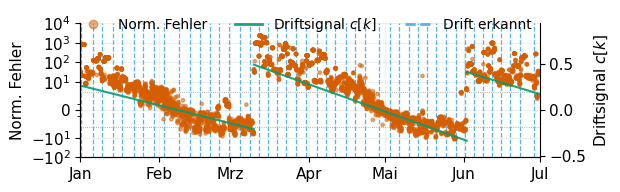

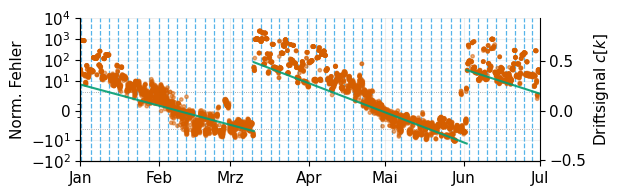

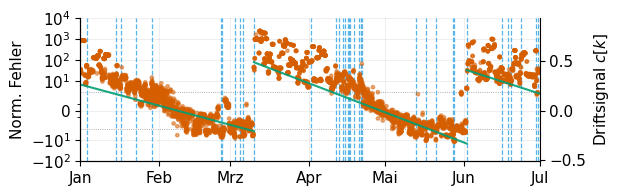

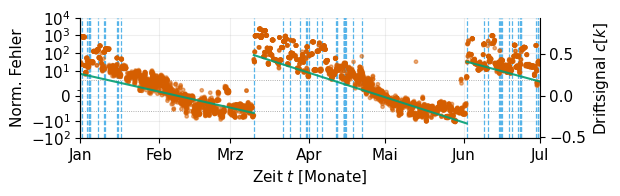

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

PLOT_END = pd.Timestamp("1970-07-01")
pdat = test_data.loc[:PLOT_END]
n_plot = len(pdat)
err_vals = np.nan_to_num(pdat["pred_error_norm_cd"].values)
rng_plot = np.random.default_rng(SEED)

detections = {"KSWIN": plot_thinned["KSWIN"][0], "ADWIN": plot_thinned["ADWIN"][0],
              "DDM": tuned["DDM"][0], "EDDM": tuned["EDDM"][0]}

for j, (name, drifts) in enumerate(detections.items()):
    fig, ax, ax2 = ts.error_timeseries(
        pdat.index,
        [(err_vals, "drift_afflicted", "Norm. Fehler")],
        cd=pdat["cd"].values,
        detections=[pdat.index[d] for d in drifts if d < n_plot],
        xlabel="Zeit $t$ [Monate]" if j == len(detections) - 1 else None,
        ylim=(-1e2, 1e4), frac=0.02, rng=rng_plot,
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=3) if j == 0 else False,
    )
    fig.tight_layout()
    if not _detections_loaded_from_cache:
        plot_store.save_figure(fig, f"detection_{name.lower()}", det_run, final=IS_FINAL, savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
    plt.show()


## Ergebnisse speichern

In [9]:
from src.utils import results_export as rx

N = len(error_stream)

def _full_metrics(drifts):
    return dd.score_detections(drifts, sudden_idx, drift_active, tolerance=TOLERANCE, n=N)

detector_results = {}
for _name in ["KSWIN", "ADWIN", "DDM", "EDDM", "RMSE"]:
    _ua = studies[_name].best_trial.user_attrs
    _drifts = tuned[_name][0]
    _m = _full_metrics(_drifts)
    _entry = {
        "best_params": best_params[_name],
        "tuning_metrics": {_k: _ua.get(_k) for _k in
            ["recall", "mean_delay", "n_false", "fa_per_true", "n_sudden", "n_detected", "score"]},
        "tuning_score": studies[_name].best_value,
        "full_stream": {"n_detected": _m["n_detected"], "recall": _m["recall"],
                        "mean_delay": _m["mean_delay"], "n_false": _m["n_false"]},
        "drift_indices": list(_drifts),
    }
    if _name in plot_thinned:
        _entry["plot_thinned"] = {"plot_cooldown": COOLDOWN,
                                  "n_shown": len(plot_thinned[_name][0])}
    detector_results[_name] = _entry

(rx.ResultDoc()
   .integer("n_samples", N)
   .integer("n_sudden_drifts", len(sudden_idx))
   .set("sudden_drift_indices", sudden_idx)
   .integer("n_active", np.sum(drift_active))
   .set("tolerance", TOLERANCE)
   .set("plot_cooldown", COOLDOWN)
   .set("tuning", {"n_trials": 40, "downsample": 1, "weights": [3.0, 0.3, 0.05]})
   .set("detectors", detector_results)
   .save(res_store, "detection", det_run, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\syn_detection.json


'C:\\git\\process_optimization_concept_drift\\results\\syn_detection.json'

In [10]:
from src.utils import latex_export as lx

mx = lx.MacroExport("Automatisch erzeugt aus syn_detection.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant)")
mx.param("paramNTol", TOLERANCE)   # Toleranzfenster n_tol [Abtastschritte]
mx.integer("paramRefract", COOLDOWN)

mx.comment("Ergebnisse (Detektionskennzahlen je Detektor)")
for _name in ["KSWIN", "ADWIN", "DDM", "EDDM", "RMSE"]:
    _e = detector_results[_name]; _fs = _e["full_stream"]
    mx.num(f"drift{_name}Recall", _fs["recall"], 2)
    mx.num(f"drift{_name}Delay",  _fs["mean_delay"], 0)
    mx.integer(f"drift{_name}False",  _fs["n_false"])
    mx.integer(f"drift{_name}Drifts", _fs["n_detected"])
    if "plot_thinned" in _e:
        mx.integer(f"drift{_name}DriftsPlot", _e["plot_thinned"]["n_shown"])

mx.save(res_store, "detection", det_run, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\syn_detection.tex

% Automatisch erzeugt aus syn_detection.ipynb - nicht manuell editieren

% Parameter (Hash-relevant)
\newcommand{\paramNTol}{1000}
\newcommand{\paramRefract}{5000}

% Ergebnisse (Detektionskennzahlen je Detektor)
\newcommand{\driftKSWINRecall}{1{,}00}
\newcommand{\driftKSWINDelay}{145}
\newcommand{\driftKSWINFalse}{42}
\newcommand{\driftKSWINDrifts}{854}
\newcommand{\driftKSWINDriftsPlot}{91}
\newcommand{\driftADWINRecall}{1{,}00}
\newcommand{\driftADWINDelay}{148}
\newcommand{\driftADWINFalse}{99}
\newcommand{\driftADWINDrifts}{1017}
\newcommand{\driftADWINDriftsPlot}{98}
\newcommand{\driftDDMRecall}{1{,}00}
\newcommand{\driftDDMDelay}{329}
\newcommand{\driftDDMFalse}{0}
\newcommand{\driftDDMDrifts}{72}
\newcommand{\driftEDDMRecall}{1{,}00}
\newcommand{\driftEDDMDelay}{332}
\newcommand{\driftEDDMFalse}{0}
\newcommand{\driftEDDMDrifts}{89}
\newcommand{\driftRMSERecall}{1{,}00}
\newcommand{\driftRMSEDel

'C:\\git\\process_optimization_concept_drift\\results\\syn_detection.tex'